In [13]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [15]:
data = pd.read_csv('Housing.csv')

In [17]:
# Quick look at the data
print("First few rows of the dataset:")
print(data.head())

First few rows of the dataset:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [19]:
data = data.dropna()

In [21]:
label_enc = LabelEncoder()
for col in ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']:
    data[col] = label_enc.fit_transform(data[col])

In [23]:
# 4. SIMPLE LINEAR REGRESSION (Area vs Price)
X_simple = data[['area']]  
y_simple = data['price']  

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)


In [27]:
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Predictions
y_pred = model_simple.predict(X_test)

# Evaluation
print("\n--- Simple Linear Regression Results ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"Coefficient (Slope): {model_simple.coef_[0]:.2f}")
print(f"Intercept: {model_simple.intercept_:.2f}")


--- Simple Linear Regression Results ---
MAE: 1474748.13
MSE: 3675286604768.19
R² Score: 0.27
Coefficient (Slope): 425.73
Intercept: 2512254.26



--- Simple Linear Regression Results ---


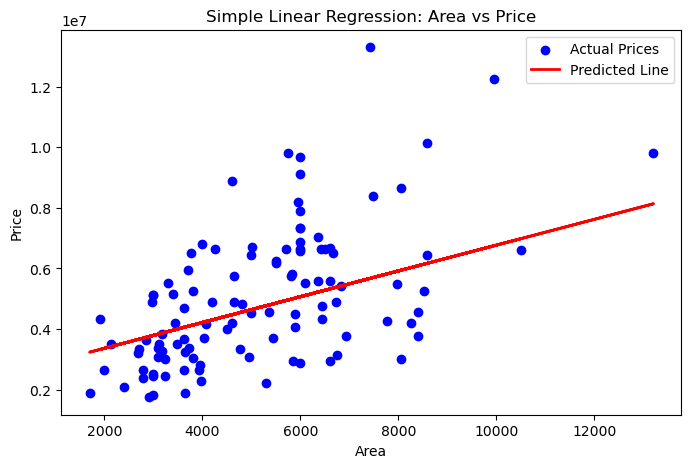

In [29]:
#Simple Linear Regression
print("\n--- Simple Linear Regression Results ---")
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color='blue', label='Actual Prices')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Line')
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Simple Linear Regression: Area vs Price')
plt.legend()
plt.show()

In [33]:
# 5. MULTIPLE LINEAR REGRESSION (Using multiple features)
features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 
            'mainroad', 'guestroom', 'basement', 'hotwaterheating', 
            'airconditioning', 'prefarea', 'furnishingstatus']
X_multiple = data[features]
y_multiple = data['price']

# Train-test split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)

# Model training
model_multiple = LinearRegression()
model_multiple.fit(X_train_m, y_train_m)

# Predictions
y_pred_m = model_multiple.predict(X_test_m)

# Evaluation
print("\n--- Multiple Linear Regression Results ---")
print(f"MAE: {mean_absolute_error(y_test_m, y_pred_m):.2f}")
print(f"MSE: {mean_squared_error(y_test_m, y_pred_m):.2f}")
print(f"R² Score: {r2_score(y_test_m, y_pred_m):.2f}")
print(f"Coefficients: {model_multiple.coef_}")
print(f"Intercept: {model_multiple.intercept_:.2f}")





--- Multiple Linear Regression Results ---
MAE: 979679.69
MSE: 1771751116594.03
R² Score: 0.65
Coefficients: [ 2.35848772e+02  7.85744924e+04  1.09711727e+06  4.06223164e+05
  2.25756514e+05  3.66824192e+05  2.33146766e+05  3.93159779e+05
  6.87881311e+05  7.85550579e+05  6.29901661e+05 -2.10397118e+05]
Intercept: 293083.07


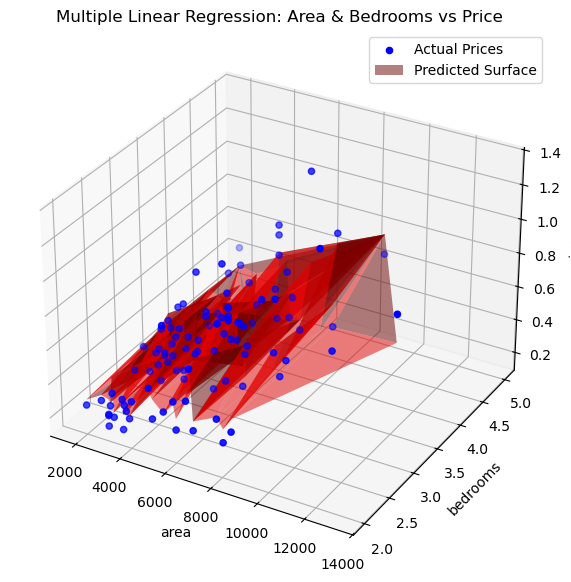

In [35]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test_m['area'], X_test_m['bedrooms'], y_test_m, color='blue', label='Actual Prices')
ax.plot_trisurf(X_test_m['area'], X_test_m['bedrooms'], y_pred_m, color='red', alpha=0.5, label='Predicted Surface')
ax.set_xlabel('area')
ax.set_ylabel('bedrooms')
ax.set_zlabel('price')
ax.set_title('Multiple Linear Regression: Area & Bedrooms vs Price')
ax.legend()
plt.show()